In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import os

In [14]:
os.listdir('../../../../optimized_results/acc_at_k/original/original_output.csv')

['original_output.csv']

In [27]:
df = pd.read_csv('../../../../optimized_results/acc_at_k/original/original_output.csv')

In [23]:
def get_acc_at_inter(dataframe):
    df_new = dataframe.copy(deep=True)

    for col in [x for x in df_new.columns if 'pred_' in x]:
        df_new[col] = (df_new[col] == df_new['trackId']).astype(int)

    wanted_cols = [x for x in df_new.columns if 'pred_' in x]

    df_new[wanted_cols] = df_new[wanted_cols].cumsum(axis=1)

    df_new["interaction_num"] = df_new.groupby(["userId", "trackId"]).cumcount() + 1

    result_list = []

    for col in wanted_cols:
        temp = (
            df_new.groupby("interaction_num")[col]
            .agg(accuracy="mean", count="size")
            .reset_index()
        )
        temp["col_name"] = col
        result_list.append(temp)

    accuracy = pd.concat(result_list, ignore_index=True)
    return accuracy

In [28]:
df

,interaction_num,accuracy,count,col_name
0,1,0.002309,26418,pred_1
1,2,0.003610,14960,pred_1
2,3,0.004802,10204,pred_1
3,4,0.006116,7685,pred_1
4,5,0.007588,6062,pred_1
...,...,...,...,...
12345,243,0.000000,1,pred_50
12346,244,0.000000,1,pred_50
12347,245,0.000000,1,pred_50
12348,246,0.000000,1,pred_50


In [29]:
out = df
pred_cols = [col for col in df.columns if col.startswith("pred_")]

accuracy_df = (
    df
    .assign(**{f"acc_{col}": (df[col] == df["trackId"]).astype(int) for col in pred_cols})
    .groupby("trackId")[[f"acc_{c}" for c in pred_cols]]
    .mean()
    .reset_index()
)

final_df = item_counts.merge(accuracy_df.rename(columns={'trackId': 'track_id'}), on="track_id", how="left")

KeyError: 'trackId'

In [25]:
final_df

NameError: name 'final_df' is not defined

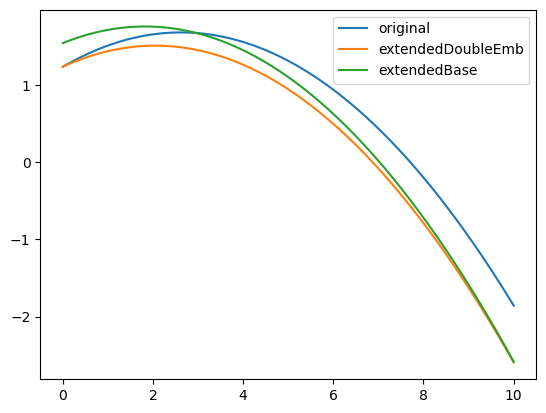

In [20]:
models = ['original', 'extendedDoubleEmb', 'extendedBase']

plt.figure()
for m in models:
    checkpoint_path = f"../train_notebooks/{m}.pt"
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

    a = checkpoint['model_state_dict']['alpha'].numpy()
    b = checkpoint['model_state_dict']['beta'].numpy()
    c = checkpoint['model_state_dict']['gamma'].numpy()

    x = np.linspace(0, 10, 100)

    y = a*x + b*x**2 + c 


    plt.plot(x,y, label=m)
plt.legend()

In [30]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

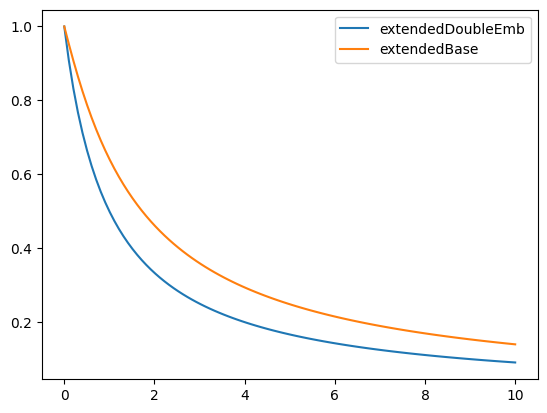

In [40]:
models_ext = ['extendedDoubleEmb', 'extendedBase']

plt.figure()
for m in models_ext:
    checkpoint_path = f"../train_notebooks/{m}.pt"
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

    s = checkpoint['model_state_dict']['smooth'].numpy()
    f = checkpoint['model_state_dict']['force'].numpy()

    x = np.linspace(0, 10, 100)

    weight = sigmoid(s/(1+x)-f*s)/sigmoid(s-f*s)
    y = np.clip((1/(1+x))*weight, 0.0, 1.0)

    plt.plot(x,y, label=m)
plt.legend()